In [1]:
%pip install pandas matplotlib seaborn plotly statsmodels

Note: you may need to restart the kernel to use updated packages.


In [19]:
import glob
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
import statsmodels.formula.api as smf

In [3]:
# Data import & cleaning
r_and_d_expenditure = pd.read_csv('data/API_GB.XPD.RSDV.GD.ZS_DS2_en_csv_v2_232.csv', skiprows=4)
researchers_per_million = pd.read_csv('data/API_SP.POP.SCIE.RD.P6_DS2_en_csv_v2_37695.csv', skiprows=4)
PM_Exposure = pd.read_csv('data/API_EN.ATM.PM25.MC.M3_DS2_en_csv_v2_33524.csv', skiprows=4)
GDP_data = pd.read_csv('data/API_NY.GDP.PCAP.CD_DS2_en_csv_v2_33610.csv', skiprows=4)

In [4]:
r_and_d_expenditure

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,Research and development expenditure (% of GDP),GB.XPD.RSDV.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,Research and development expenditure (% of GDP),GB.XPD.RSDV.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,Research and development expenditure (% of GDP),GB.XPD.RSDV.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Africa Western and Central,AFW,Research and development expenditure (% of GDP),GB.XPD.RSDV.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.277537,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Angola,AGO,Research and development expenditure (% of GDP),GB.XPD.RSDV.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260,Kosovo,XKX,Research and development expenditure (% of GDP),GB.XPD.RSDV.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
261,"Yemen, Rep.",YEM,Research and development expenditure (% of GDP),GB.XPD.RSDV.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
262,South Africa,ZAF,Research and development expenditure (% of GDP),GB.XPD.RSDV.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,0.76257,0.68586,0.613040,0.60296,0.6139,0.61479,NaN,NaN,NaN,NaN
263,Zambia,ZMB,Research and development expenditure (% of GDP),GB.XPD.RSDV.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
researchers_per_million

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,Researchers in R&D (per million people),SP.POP.SCIE.RD.P6,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,Researchers in R&D (per million people),SP.POP.SCIE.RD.P6,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,Researchers in R&D (per million people),SP.POP.SCIE.RD.P6,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Africa Western and Central,AFW,Researchers in R&D (per million people),SP.POP.SCIE.RD.P6,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Angola,AGO,Researchers in R&D (per million people),SP.POP.SCIE.RD.P6,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260,Kosovo,XKX,Researchers in R&D (per million people),SP.POP.SCIE.RD.P6,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
261,"Yemen, Rep.",YEM,Researchers in R&D (per million people),SP.POP.SCIE.RD.P6,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
262,South Africa,ZAF,Researchers in R&D (per million people),SP.POP.SCIE.RD.P6,NaN,NaN,NaN,NaN,NaN,NaN,...,516.53674,500.79079,479.86558,459.98774,454.79773,444.16298,NaN,NaN,NaN,NaN
263,Zambia,ZMB,Researchers in R&D (per million people),SP.POP.SCIE.RD.P6,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
PM_Exposure

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,"PM2.5 air pollution, mean annual exposure (mic...",EN.ATM.PM25.MC.M3,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,"PM2.5 air pollution, mean annual exposure (mic...",EN.ATM.PM25.MC.M3,NaN,NaN,NaN,NaN,NaN,NaN,...,24.786789,24.875242,26.282024,25.660129,25.529458,26.383916,25.283403,NaN,NaN,NaN
2,Afghanistan,AFG,"PM2.5 air pollution, mean annual exposure (mic...",EN.ATM.PM25.MC.M3,NaN,NaN,NaN,NaN,NaN,NaN,...,37.066798,40.838489,34.795214,34.164126,39.738833,40.206779,37.948311,NaN,NaN,NaN
3,Africa Western and Central,AFW,"PM2.5 air pollution, mean annual exposure (mic...",EN.ATM.PM25.MC.M3,NaN,NaN,NaN,NaN,NaN,NaN,...,53.058490,47.264084,44.582794,49.711336,49.335972,53.622398,50.424014,NaN,NaN,NaN
4,Angola,AGO,"PM2.5 air pollution, mean annual exposure (mic...",EN.ATM.PM25.MC.M3,NaN,NaN,NaN,NaN,NaN,NaN,...,18.226159,19.927565,22.174344,19.570648,18.490841,22.517224,19.907569,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260,Kosovo,XKX,"PM2.5 air pollution, mean annual exposure (mic...",EN.ATM.PM25.MC.M3,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
261,"Yemen, Rep.",YEM,"PM2.5 air pollution, mean annual exposure (mic...",EN.ATM.PM25.MC.M3,NaN,NaN,NaN,NaN,NaN,NaN,...,47.973257,45.663183,48.335147,43.734771,41.734805,47.114649,46.835978,NaN,NaN,NaN
262,South Africa,ZAF,"PM2.5 air pollution, mean annual exposure (mic...",EN.ATM.PM25.MC.M3,NaN,NaN,NaN,NaN,NaN,NaN,...,28.757631,27.773423,28.869769,28.326217,27.722593,28.506282,27.724711,NaN,NaN,NaN
263,Zambia,ZMB,"PM2.5 air pollution, mean annual exposure (mic...",EN.ATM.PM25.MC.M3,NaN,NaN,NaN,NaN,NaN,NaN,...,19.815295,21.114438,22.120533,19.448496,19.592501,23.490185,20.243049,NaN,NaN,NaN


In [7]:
GDP_data

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,28440.041688,30082.158423,30654.485124,22664.370995,26827.344787,31000.571380,34897.618393,38590.565029,NaN,NaN
1,Africa Eastern and Southern,AFE,GDP per capita (current US$),NY.GDP.PCAP.CD,186.089515,186.909365,197.367876,225.400456,208.963066,226.836513,...,1529.923080,1553.617944,1508.031525,1351.503167,1560.894626,1675.902524,1571.132704,1628.227289,1722.385620,NaN
2,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,525.469771,491.337221,496.602504,510.787063,356.496214,357.261153,413.757895,416.871146,NaN,NaN
3,Africa Western and Central,AFW,GDP per capita (current US$),NY.GDP.PCAP.CD,121.936832,127.451040,133.823783,139.004980,148.551510,155.587905,...,1577.203497,1723.114463,2219.412555,2034.437940,2116.938294,2143.072094,1846.246811,1416.228412,1600.058374,NaN
4,Angola,AGO,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,2832.149980,2891.830324,2507.868072,1749.179484,2266.968349,3598.536691,2885.513491,2720.819007,3129.476623,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260,Kosovo,XKX,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,4009.320221,4384.187964,4415.699274,4320.583825,5269.699462,5298.147387,6220.332139,7026.698813,7899.418411,NaN
261,"Yemen, Rep.",YEM,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,811.165970,633.887202,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
262,South Africa,ZAF,GDP per capita (current US$),NY.GDP.PCAP.CD,532.147504,545.657512,563.423009,604.536855,645.873376,684.621228,...,6618.335083,6914.178032,6533.711210,5580.603831,6828.756246,6534.248678,6034.272090,6267.186814,6597.714509,NaN
263,Zambia,ZMB,GDP per capita (current US$),NY.GDP.PCAP.CD,221.559849,209.693206,202.281031,203.219451,229.979246,287.425476,...,1483.465773,1463.899979,1258.986198,951.644317,1127.160779,1447.123101,1330.727806,1187.109434,1317.877716,NaN


In [8]:
r_and_d_expenditure = r_and_d_expenditure.drop(columns=[c for c in r_and_d_expenditure.columns if "Unnamed" in c])
years = [c for c in r_and_d_expenditure.columns if c[:4].isdigit()]
r_and_d_expenditure = r_and_d_expenditure.melt(id_vars=["Country Name", "Country Code"],          # = Unpivot Other Columns
                                   value_vars=years, var_name="Year", value_name="R&D Expenditure")
r_and_d_expenditure = r_and_d_expenditure.dropna(subset=["R&D Expenditure"])
r_and_d_expenditure["Year"] = r_and_d_expenditure["Year"].astype(int)
r_and_d_expenditure

,Country Name,Country Code,Year,R&D Expenditure
9549,Argentina,ARG,1996,0.41749
9553,Australia,AUS,1996,1.66218
9554,Austria,AUT,1996,1.58947
9555,Azerbaijan,AZE,1996,0.23533
9557,Belgium,BEL,1996,1.74299
...,...,...,...,...
17164,Saudi Arabia,SAU,2024,0.63522
17173,Serbia,SRB,2024,0.93978
17191,Togo,TGO,2024,0.22229
17207,Ukraine,UKR,2024,0.36988


In [9]:
researchers_per_million = researchers_per_million.drop(columns=[c for c in researchers_per_million.columns if "Unnamed" in c])
years = [c for c in researchers_per_million.columns if c[:4].isdigit()]
researchers_per_million = researchers_per_million.melt(id_vars=["Country Name", "Country Code"],          # = Unpivot Other Columns
                                   value_vars=years, var_name="Year", value_name="Researchers per Million")
researchers_per_million = researchers_per_million.dropna(subset=["Researchers per Million"])
researchers_per_million["Year"] = researchers_per_million["Year"].astype(int)
researchers_per_million

,Country Name,Country Code,Year,Researchers per Million
9553,Australia,AUS,1996,3353.705300
9557,Belgium,BEL,1996,2477.439060
9561,Bulgaria,BGR,1996,1771.854220
9575,Canada,CAN,1996,3055.672470
9576,Central Europe and the Baltics,CEB,1996,1410.613645
...,...,...,...,...
17173,Serbia,SRB,2024,2687.547080
17191,Togo,TGO,2024,57.794020
17202,Tunisia,TUN,2024,1667.611640
17209,Uruguay,URY,2024,937.570390


In [10]:
PM_Exposure = PM_Exposure.drop(columns=[c for c in PM_Exposure.columns if "Unnamed" in c])
years = [c for c in PM_Exposure.columns if c[:4].isdigit()]
PM_Exposure = PM_Exposure.melt(id_vars=["Country Name", "Country Code"],          # = Unpivot Other Columns
                               value_vars=years, var_name="Year", value_name="PM Exposure")
PM_Exposure = PM_Exposure.dropna(subset=["PM Exposure"])
PM_Exposure["Year"] = PM_Exposure["Year"].astype(int)
PM_Exposure

,Country Name,Country Code,Year,PM Exposure
7951,Africa Eastern and Southern,AFE,1990,23.793024
7952,Afghanistan,AFG,1990,48.426586
7953,Africa Western and Central,AFW,1990,51.095358
7954,Angola,AGO,1990,23.676964
7955,Albania,ALB,1990,23.494611
...,...,...,...,...
16954,Samoa,WSM,2023,4.579499
16956,"Yemen, Rep.",YEM,2023,46.835978
16957,South Africa,ZAF,2023,27.724711
16958,Zambia,ZMB,2023,20.243049


In [11]:
GDP_data = GDP_data.drop(columns=[c for c in GDP_data.columns if "Unnamed" in c])
years = [c for c in GDP_data.columns if c[:4].isdigit()]
GDP_data = GDP_data.melt(id_vars=["Country Name", "Country Code"],          # = Unpivot Other Columns
                               value_vars=years, var_name="Year", value_name="GDP per Capita")
GDP_data = GDP_data.dropna(subset=["GDP per Capita"])
GDP_data["Year"] = GDP_data["Year"].astype(int)
GDP_data

,Country Name,Country Code,Year,GDP per Capita
1,Africa Eastern and Southern,AFE,1960,186.089515
3,Africa Western and Central,AFW,1960,121.936832
9,Argentina,ARG,1960,778.251707
13,Australia,AUS,1960,1813.431099
14,Austria,AUT,1960,939.914815
...,...,...,...,...
17484,Samoa,WSM,2025,5872.783333
17485,Kosovo,XKX,2025,7899.418411
17487,South Africa,ZAF,2025,6597.714509
17488,Zambia,ZMB,2025,1317.877716


In [12]:
df = r_and_d_expenditure.merge(PM_Exposure, on=["Country Name", "Country Code", "Year"], how="inner")
df = df.merge(researchers_per_million, on=["Country Name", "Country Code", "Year"], how="inner")
df = df.merge(GDP_data, on=["Country Name", "Country Code", "Year"], how="inner")
df = df.rename(columns={
    "R&D Expenditure": "RnDPctGDP",
    "PM Exposure":     "PM25",
    "GDP per Capita":  "GDPperCapita",
})
df, print(df.columns.tolist())

['Country Name', 'Country Code', 'Year', 'RnDPctGDP', 'PM25', 'Researchers per Million', 'GDPperCapita']


(                        Country Name Country Code  Year  RnDPctGDP       PM25  \
 0                          Australia          AUS  1996   1.662180   6.242747   
 1                            Belgium          BEL  1996   1.742990  21.208457   
 2                           Bulgaria          BGR  1996   0.418260  29.507236   
 3                             Canada          CAN  1996   1.606820   9.154540   
 4     Central Europe and the Baltics          CEB  1996   0.718818  26.687557   
 ...                              ...          ...   ...        ...        ...   
 2295                         Turkiye          TUR  2023   1.422240  26.404160   
 2296                          Uganda          UGA  2023   0.438300  31.214824   
 2297                         Uruguay          URY  2023   0.701960  10.854802   
 2298                      Uzbekistan          UZB  2023   0.110930  32.771372   
 2299                        Viet Nam          VNM  2023   0.414560  24.784548   
 
       Researc

In [13]:
# Data visualization
px.choropleth(df, locations="Country Code", color="PM25", locationmode="ISO-3").show()

<Axes: xlabel='RnDPctGDP', ylabel='PM25'>

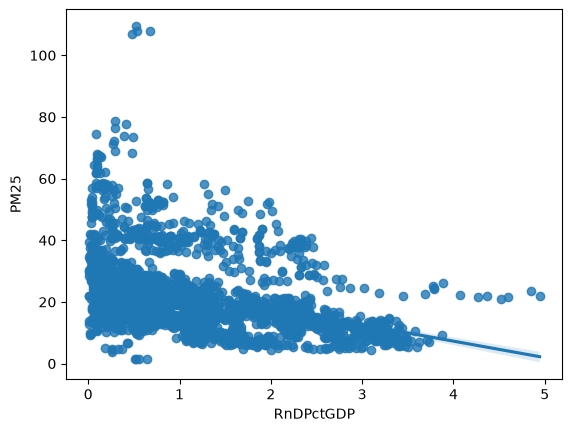

In [14]:
sns.regplot(x="RnDPctGDP", y="PM25", data=df)

In [15]:
df = df[df.Year == 2023].copy()
df["logGDP"] = np.log10(df["GDPperCapita"])

m1 = smf.ols("PM25 ~ RnDPctGDP", data=df).fit()
m2 = smf.ols("PM25 ~ RnDPctGDP + logGDP", data=df).fit()
print(m2.summary())
m3 = smf.ols("PM25 ~ logGDP + I(logGDP**2)", data=df).fit()
smf.ols("PM25 ~ RnDPctGDP + logGDP", data=df)

                            OLS Regression Results                            
Dep. Variable:                   PM25   R-squared:                       0.310
Model:                            OLS   Adj. R-squared:                  0.292
Method:                 Least Squares   F-statistic:                     17.30
Date:                Wed, 15 Jul 2026   Prob (F-statistic):           6.25e-07
Time:                        22:05:17   Log-Likelihood:                -303.19
No. Observations:                  80   AIC:                             612.4
Df Residuals:                      77   BIC:                             619.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     70.9748     11.759      6.036      0.0

In [18]:
for name, m in [("naive", m1), ("controlled", m2)]:
    print(f"{name:11s} R&D coef = {m.params['RnDPctGDP']:7.3f}  p = {m.pvalues['RnDPctGDP']:.4f}  n = {int(m.nobs)}")

naive       R&D coef =  -4.956  p = 0.0001  n = 80
controlled  R&D coef =  -1.681  p = 0.2342  n = 80


In [21]:
YEAR = 2023

# outer join, not inner: keep every country-year any indicator has.
# Chaining inner joins silently guts the sample -- and it makes the
# "who reports R&D?" map impossible, because non-reporters get dropped.
full = r_and_d_expenditure[["Country Code", "Year", "R&D Expenditure"]]
for table, col in [(PM_Exposure, "PM Exposure"),
                   (researchers_per_million, "Researchers per Million"),
                   (GDP_data, "GDP per Capita")]:
    full = full.merge(table[["Country Code", "Year", col]],
                      on=["Country Code", "Year"], how="outer")

# Join on Country Code only, then attach names once. Codes are unambiguous;
# country *names* can drift between files (Turkey -> Turkiye) and silently
# break a join.
names = (pd.concat([t[["Country Code", "Country Name"]] for t in
                    (r_and_d_expenditure, PM_Exposure,
                     researchers_per_million, GDP_data)])
         .drop_duplicates("Country Code"))
full = full.merge(names, on="Country Code", how="left")

full = full.rename(columns={"R&D Expenditure":         "RnDPctGDP",
                            "PM Exposure":             "PM25",
                            "GDP per Capita":          "GDPperCapita",
                            "Researchers per Million": "ResearchersPerM"},
                   errors="raise")   # raise = tell me loudly if a name misses

print(f"full: {len(full):,} rows, {full.Year.min()}-{full.Year.max()}")

full: 14,928 rows, 1960-2025


In [22]:
# Flag aggregates rather than deleting them: the regression must EXCLUDE them,
# but the regional trend chart is built FROM them.
INCOME = {"HIC", "LIC", "LMC", "UMC", "MIC", "LMY", "INX"}
AGGS = {"AFE","AFW","ARB","CEB","CSS","EAP","EAR","EAS","ECA","ECS","EMU","EUU",
        "FCS","HIC","HPC","IBD","IBT","IDA","IDB","IDX","INX","LAC","LCN","LDC",
        "LIC","LMC","LMY","LTE","MEA","MIC","MNA","NAC","OED","OSS","PRE","PSS",
        "PST","SAS","SSA","SSF","SST","TEA","TEC","TLA","TMN","TSA","TSS","UMC",
        "WLD"}

def area_type(code):
    if code == "WLD":  return "World"
    if code in INCOME: return "Income group"
    if code in AGGS:   return "Region"
    return "Country"

full["AreaType"] = full["Country Code"].map(area_type)
print(full["AreaType"].value_counts().to_string())

AreaType
Country         11947
Region           2519
Income group      396
World              66


In [23]:
# Countries only, one year, complete cases.
#   AreaType == "Country" -> no World/region rows contaminating the model
#   Year == YEAR          -> a country's 2023 is nearly its 2022; pooling all
#                            years fakes independence and inflates significance
#   dropna(subset=...)    -> m1 and m2 must see IDENTICAL rows, or the
#                            coefficient comparison isn't apples-to-apples
d = full[(full.Year == YEAR) & (full.AreaType == "Country")].dropna(
        subset=["PM25", "RnDPctGDP", "GDPperCapita"]).copy()
d["logGDP"] = np.log10(d["GDPperCapita"])

m1c = smf.ols("PM25 ~ RnDPctGDP", data=d).fit()              # naive
m2c = smf.ols("PM25 ~ RnDPctGDP + logGDP", data=d).fit()     # + income control
m3c = smf.ols("PM25 ~ logGDP + I(logGDP**2)", data=d).fit()  # hump test

print(f"original sample (aggregates included): n = {int(m2.nobs)}")
print(f"countries only:                        n = {int(m2c.nobs)}")
print(f"  -> {int(m2.nobs) - int(m2c.nobs)} of your original rows were not countries\n")

# The finding is the coefficient MOVING between these two:
for label, m in [("naive", m1c), ("controlled", m2c)]:
    print(f"{label:11s} R&D beta = {m.params['RnDPctGDP']:7.3f}   "
          f"p = {m.pvalues['RnDPctGDP']:.4f}   "
          f"n = {int(m.nobs)}   adj R2 = {m.rsquared_adj:.3f}")

original sample (aggregates included): n = 80
countries only:                        n = 80
  -> 0 of your original rows were not countries

naive       R&D beta =  -4.522   p = 0.0001   n = 80   adj R2 = 0.175
controlled  R&D beta =  -1.411   p = 0.2783   n = 80   adj R2 = 0.294


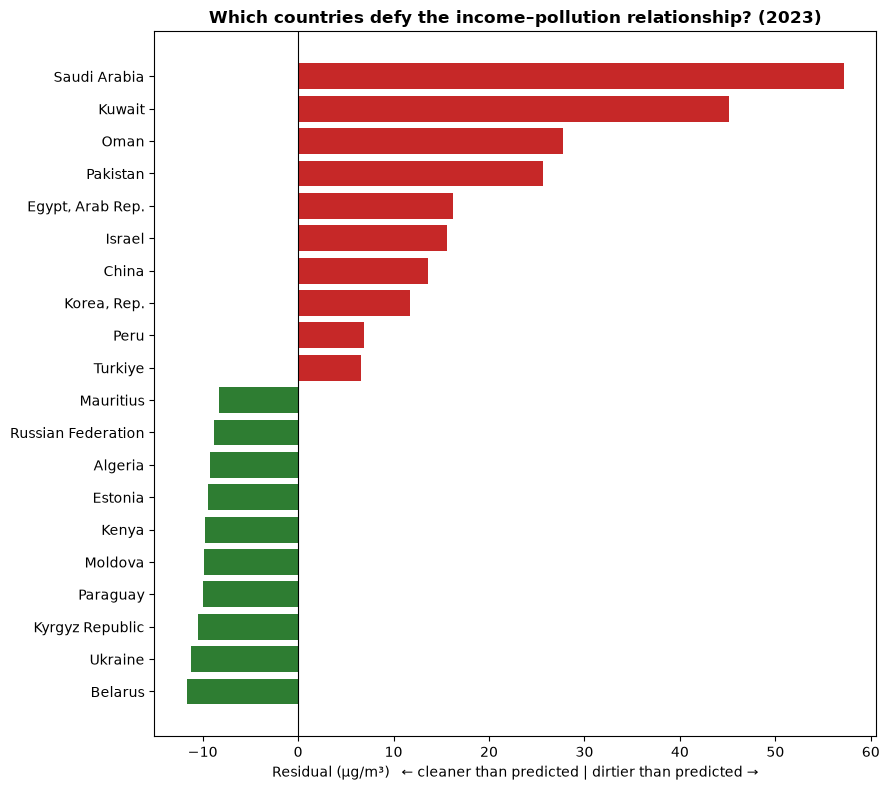

Dirtier than income predicts:
    Country Name      PM25  GDPperCapita     resid
    Saudi Arabia 73.517975  36156.856250 57.151820
          Kuwait 62.348436  34091.971481 45.134632
            Oman 46.855758  21027.738457 27.701875
        Pakistan 58.374518   1360.324178 25.692419
Egypt, Arab Rep. 43.146055   3456.789652 16.197086
          Israel 21.900848  52126.448928 15.557428
           China 31.991575  12951.178240 13.602768
     Korea, Rep. 21.894023  35674.095996 11.739534

Cleaner than income predicts:
   Country Name      PM25  GDPperCapita      resid
        Belarus 11.984375   7896.753883 -11.622090
        Ukraine 14.854702   5139.598145 -11.181611
Kyrgyz Republic 20.123901   2138.222102 -10.527981
       Paraguay 15.327994   6303.264950  -9.977437
        Moldova 14.945092   6799.585946  -9.881328
          Kenya 20.252366   1942.588028  -9.804788
        Estonia  5.918446  30264.006489  -9.411202
        Algeria 16.539469   5370.477235  -9.205824


In [24]:
d["resid"] = m2c.resid
extremes = pd.concat([d.nlargest(10, "resid"),
                      d.nsmallest(10, "resid")]).sort_values("resid")

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(extremes["Country Name"], extremes["resid"],
        color=["#2E7D32" if v < 0 else "#C62828" for v in extremes["resid"]])
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Residual (\u00b5g/m\u00b3)   \u2190 cleaner than predicted | "
              "dirtier than predicted \u2192")
ax.set_title(f"Which countries defy the income\u2013pollution relationship? ({YEAR})",
             fontweight="bold")
plt.tight_layout()
plt.savefig("fig1_residuals.png", dpi=150)
plt.show()

print("Dirtier than income predicts:")
print(d.nlargest(8, "resid")[["Country Name", "PM25", "GDPperCapita", "resid"]]
      .to_string(index=False))
print("\nCleaner than income predicts:")
print(d.nsmallest(8, "resid")[["Country Name", "PM25", "GDPperCapita", "resid"]]
      .to_string(index=False))

R&D-limited sample: n = 80
full sample:        n = 190
  -> 110 countries were excluded by the R&D requirement

squared term: beta = 1.960, p = 0.4285
  -> still no hump, now on the full sample. That's a solid finding.


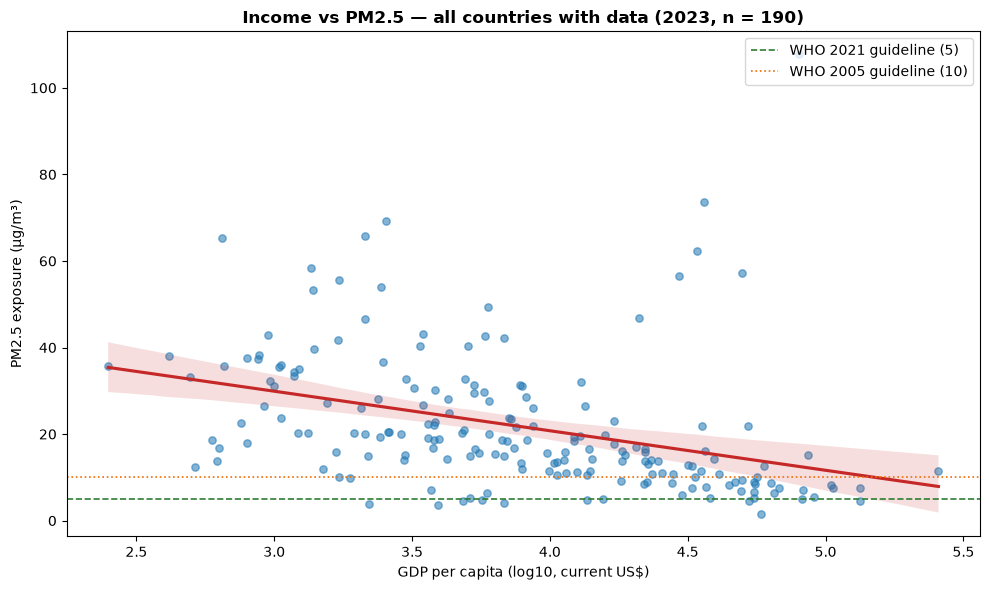

n = 190   beta = -9.137   p = 0.0000   adj R2 = 0.127


In [31]:
# Kuznets test on the FULL sample — no R&D requirement, so the poorest
# countries (Chad, DR Congo, Niger) are back in.
k = full[(full.Year == YEAR) & (full.AreaType == "Country")].dropna(
        subset=["PM25", "GDPperCapita"]).copy()
k["logGDP"] = np.log10(k["GDPperCapita"])

mk = smf.ols("PM25 ~ logGDP + I(logGDP**2)", data=k).fit()

print(f"R&D-limited sample: n = {int(m3c.nobs)}")
print(f"full sample:        n = {int(mk.nobs)}")
print(f"  -> {int(mk.nobs) - int(m3c.nobs)} countries were excluded by the R&D requirement\n")

sq = [p for p in mk.params.index if "**" in p][0]
b1, b2 = mk.params["logGDP"], mk.params[sq]
print(f"squared term: beta = {b2:.3f}, p = {mk.pvalues[sq]:.4f}")
if b2 < 0 and mk.pvalues[sq] < 0.05:
    print(f"  -> inverted-U confirmed; PM2.5 peaks near ${10**(-b1/(2*b2)):,.0f} per capita")
else:
    print("  -> still no hump, now on the full sample. That's a solid finding.")

fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(data=k, x="logGDP", y="PM25", order=1, ax=ax,
            scatter_kws=dict(s=28, alpha=0.55), line_kws=dict(color="#C62828"))
ax.axhline(5,  ls="--", c="#2E7D32", lw=1.2, label="WHO 2021 guideline (5)")
ax.axhline(10, ls=":",  c="#EF6C00", lw=1.2, label="WHO 2005 guideline (10)")
ax.set_xlabel("GDP per capita (log10, current US$)")
ax.set_ylabel("PM2.5 exposure (\u00b5g/m\u00b3)")
ax.set_title(f"Income vs PM2.5 \u2014 all countries with data ({YEAR}, n = {len(k)})",
             fontweight="bold")
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig("fig2b_kuznets_full.png", dpi=150)
plt.show()

mk_lin = smf.ols("PM25 ~ logGDP", data=k).fit()
print(f"n = {int(mk_lin.nobs)}   beta = {mk_lin.params['logGDP']:.3f}   "
      f"p = {mk_lin.pvalues['logGDP']:.4f}   adj R2 = {mk_lin.rsquared_adj:.3f}")

In [26]:
cov = full[(full.Year == YEAR) & (full.AreaType == "Country")].copy()
cov["Reports R&D"] = np.where(cov["RnDPctGDP"].notna(), "Reports", "No data")

fig3 = px.choropleth(cov, locations="Country Code", locationmode="ISO-3",
                     color="Reports R&D", hover_name="Country Name",
                     color_discrete_map={"Reports": "#1565C0",
                                         "No data": "#D0D0D0"},
                     title=f"Who can even be measured? R&D reporting, {YEAR}")
fig3.show()

n_rep = (cov["Reports R&D"] == "Reports").sum()
print(f"R&D coverage: {n_rep} of {len(cov)} countries report "
      f"({n_rep / len(cov):.0%})")

R&D coverage: 84 of 214 countries report (39%)


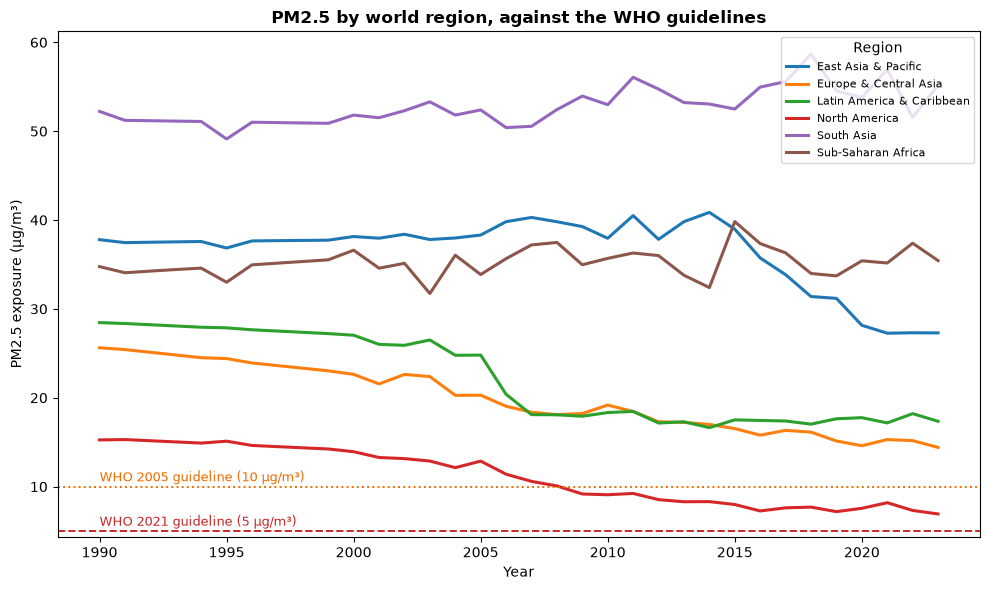

In [ ]:
REGION_CODES = ["SSF", "SAS", "EAS", "NAC", "ECS", "LCN"]
reg = full[full["Country Code"].isin(REGION_CODES)].dropna(subset=["PM25"])

fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(data=reg, x="Year", y="PM25", hue="Country Name", lw=2.2, ax=ax)
ax.axhline(5, ls="--", c="#C62828", lw=1.4)
ax.text(reg.Year.min(), 5.6, "WHO 2021 guideline (5 \u00b5g/m\u00b3)",
        color="#C62828", fontsize=9)
ax.axhline(10, ls=":", c="#EF6C00", lw=1.4)
ax.text(reg.Year.min(), 10.6, "WHO 2005 guideline (10 \u00b5g/m\u00b3)",
        color="#EF6C00", fontsize=9)
ax.set_ylabel("PM2.5 exposure (\u00b5g/m\u00b3)")
ax.set_title("PM2.5 by world region, against the WHO guidelines",
             fontweight="bold")

ax.legend(title="Region", fontsize=8, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("fig4_regional_trend.png", dpi=150)
plt.show()

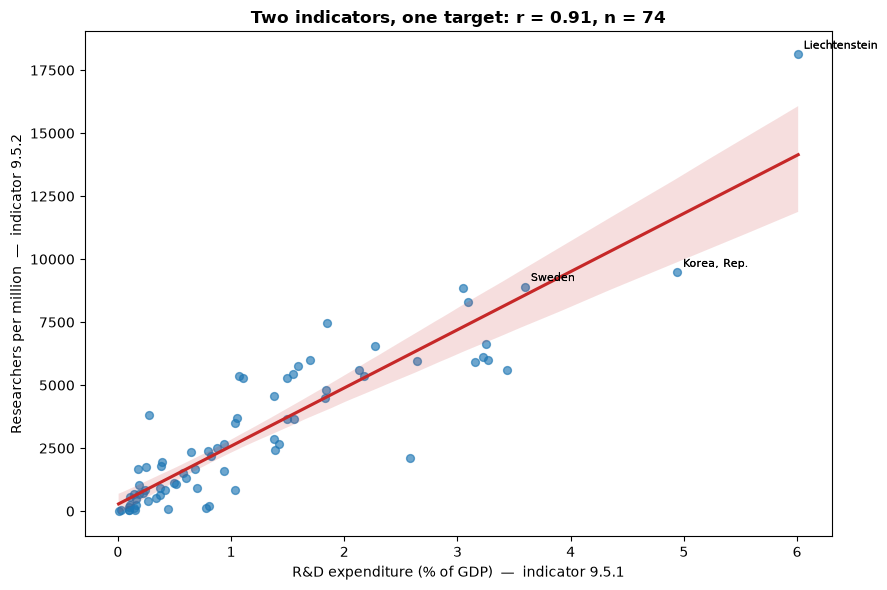

9.5.1 vs 9.5.2: r = 0.908  (r² = 0.824), n = 74


In [28]:
pair = full[(full.Year == YEAR) & (full.AreaType == "Country")].dropna(
    subset=["RnDPctGDP", "ResearchersPerM"])

fig, ax = plt.subplots(figsize=(9, 6))
sns.regplot(data=pair, x="RnDPctGDP", y="ResearchersPerM", ax=ax,
            scatter_kws=dict(s=32, alpha=0.65), line_kws=dict(color="#C62828"))
r = pair["RnDPctGDP"].corr(pair["ResearchersPerM"])
ax.set_xlabel("R&D expenditure (% of GDP)  \u2014  indicator 9.5.1")
ax.set_ylabel("Researchers per million  \u2014  indicator 9.5.2")
ax.set_title(f"Two indicators, one target: r = {r:.2f}, n = {len(pair)}",
             fontweight="bold")

for _, row in pd.concat([pair.nlargest(3, "ResearchersPerM"),
                         pair.nlargest(3, "RnDPctGDP")]).iterrows():
    ax.annotate(row["Country Name"], (row["RnDPctGDP"], row["ResearchersPerM"]),
                fontsize=8, xytext=(4, 4), textcoords="offset points")

plt.tight_layout()
plt.savefig("fig5_money_vs_people.png", dpi=150)
plt.show()

print(f"9.5.1 vs 9.5.2: r = {r:.3f}  (r\u00b2 = {r**2:.3f}), n = {len(pair)}")